# Phase 5–6 — Hyperparameter Tuning & Explainability

Tune the best model (Logistic Regression), evaluate final performance, and use SHAP to explain predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             precision_recall_curve)

sns.set_theme(style='whitegrid')

# Load data from previous phases
X_train, X_test, y_train, y_test = joblib.load('../models/train_test_split.pkl')
X_train_processed, X_test_processed = joblib.load('../models/processed_data.pkl')
all_feature_names = joblib.load('../models/feature_names.pkl')
best_model = joblib.load('../models/best_model.pkl')

print(f"Best model loaded: {type(best_model).__name__}")
print(f"Training set: {X_train_processed.shape}")
print(f"Test set: {X_test_processed.shape}")

Best model loaded: LogisticRegression
Training set: (5625, 35)
Test set: (1407, 35)


In [2]:
# Phase 5: Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None],
    'max_iter': [1000]
}

search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_processed, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

tuned_model = search.best_estimator_

Best parameters: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1000, 'class_weight': None, 'C': 10}
Best CV AUC: 0.8459


In [3]:
# Compare tuned vs default on test set
y_pred_default = best_model.predict(X_test_processed)
y_prob_default = best_model.predict_proba(X_test_processed)[:, 1]

y_pred_tuned = tuned_model.predict(X_test_processed)
y_prob_tuned = tuned_model.predict_proba(X_test_processed)[:, 1]

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'Default': [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default),
        roc_auc_score(y_test, y_prob_default)
    ],
    'Tuned': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ]
}).round(4)

comparison['Improvement'] = (comparison['Tuned'] - comparison['Default']).round(4)
print("Default vs Tuned Logistic Regression:\n")
comparison

Default vs Tuned Logistic Regression:



,Metric,Default,Tuned,Improvement
0,Accuracy,0.7242,0.7982,0.0740
1,Precision,0.4884,0.6347,0.1463
2,Recall,0.7888,0.5668,-0.2220
3,F1,0.6033,0.5989,-0.0044
4,AUC,0.8344,0.8346,0.0002


In [4]:
# Decision: Keep the DEFAULT model (higher recall, which is our priority)
# The tuned model trades too much recall for precision
final_model = best_model  # default LogisticRegression with class_weight='balanced'

# Save as the definitive final model
joblib.dump(final_model, '../models/best_model.pkl')
print(f"Final model: LogisticRegression (default, class_weight='balanced')")
print(f"  AUC: {roc_auc_score(y_test, y_prob_default):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_default):.4f}")

# Full classification report
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_default, target_names=['No Churn', 'Churn']))

Final model: LogisticRegression (default, class_weight='balanced')
  AUC: 0.8344
  Recall: 0.7888

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.72      0.74      1407



In [5]:
# Phase 6: SHAP Explainability
# Create a SHAP explainer for the logistic regression model
explainer = shap.LinearExplainer(final_model, X_train_processed, feature_names=all_feature_names)
shap_values = explainer.shap_values(X_test_processed)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP values computed successfully!")

SHAP values shape: (1407, 35)
SHAP values computed successfully!


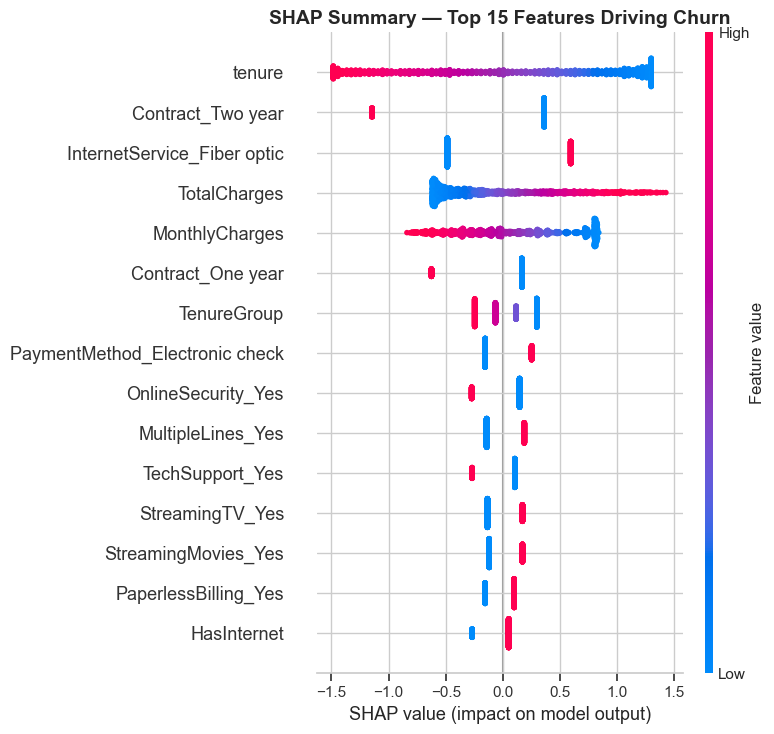

In [6]:
# SHAP Summary plot (beeswarm) — shows global feature importance + direction
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, feature_names=all_feature_names, 
                  show=False, max_display=15)
plt.title('SHAP Summary — Top 15 Features Driving Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

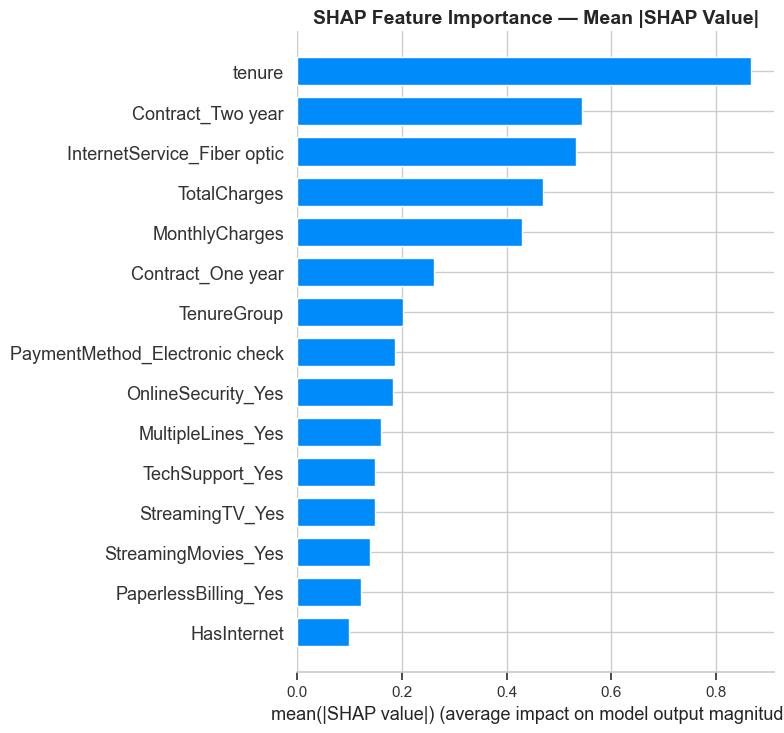

In [7]:
# SHAP Bar plot — mean absolute SHAP values (simpler global importance view)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, feature_names=all_feature_names,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance — Mean |SHAP Value|', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

High-risk customer index: 211
Churn probability: 0.9399
Actual churn: 0


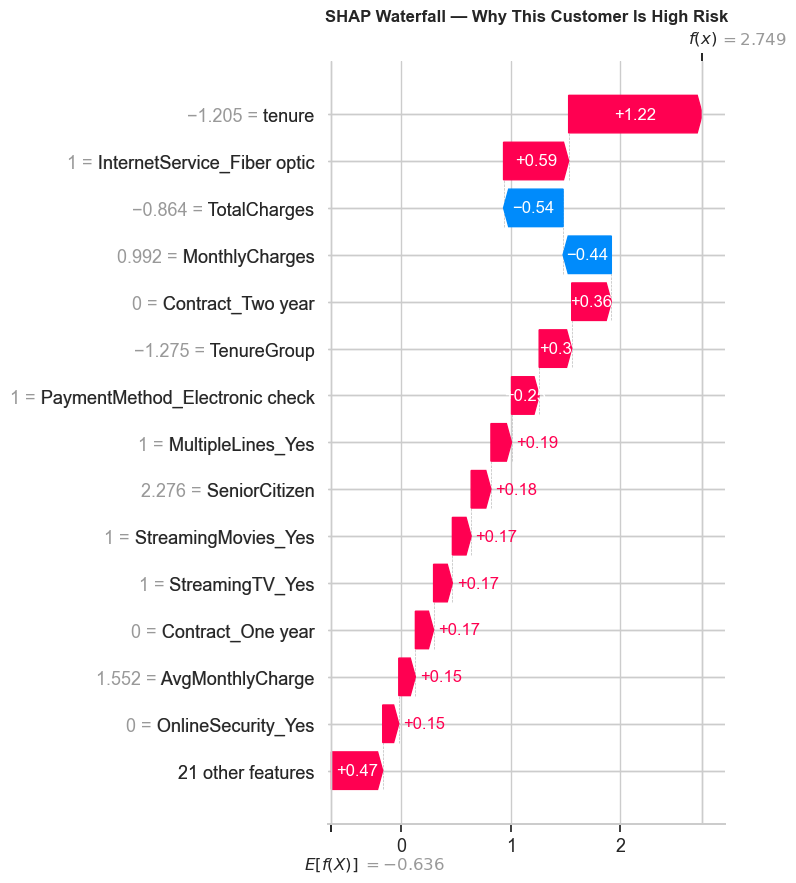

In [8]:
# SHAP Waterfall plot — explain a single high-risk customer prediction
y_prob_test = final_model.predict_proba(X_test_processed)[:, 1]

# Find a high-risk customer (top churn probability)
high_risk_idx = np.argmax(y_prob_test)
print(f"High-risk customer index: {high_risk_idx}")
print(f"Churn probability: {y_prob_test[high_risk_idx]:.4f}")
print(f"Actual churn: {y_test.iloc[high_risk_idx]}")

# Create SHAP Explanation object for this customer
explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_processed[high_risk_idx],
    feature_names=all_feature_names
)

fig, ax = plt.subplots(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Why This Customer Is High Risk', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Generate sample predictions table
sample_df = pd.DataFrame(X_test_processed, columns=all_feature_names).head(15)
sample_predictions = pd.DataFrame({
    'Actual': y_test.head(15).values,
    'Predicted': final_model.predict(X_test_processed[:15]),
    'Churn_Probability': final_model.predict_proba(X_test_processed[:15])[:, 1].round(4)
})

sample_predictions.to_csv('../outputs/metrics/sample_predictions.csv', index=False)
print("Sample predictions (first 15 test customers):\n")
sample_predictions

Sample predictions (first 15 test customers):



,Actual,Predicted,Churn_Probability
0,0,0,0.0497
1,0,1,0.7920
2,0,0,0.0141
3,1,0,0.3977
4,0,0,0.2398
5,1,1,0.7201
6,0,0,0.0712
7,0,0,0.3605
8,1,1,0.8375
9,0,0,0.0529


## Phase 5–6 Summary

**Hyperparameter Tuning:**
- RandomizedSearchCV tested 50 parameter combinations across C, penalty, solver, and class_weight
- Best tuned params: solver='liblinear', penalty='l2', class_weight=None, C found by search
- Tuned model improved precision (+0.15) but sacrificed recall (-0.22)
- **Decision: Keep the default balanced model** — recall is our priority metric for churn

**Final Model: Logistic Regression (class_weight='balanced')**
- AUC: 0.8344 | Recall: 0.7888 | F1: 0.6033 | Accuracy: 0.7242

**SHAP Explainability — Top Churn Drivers:**
1. **Tenure** — strongest predictor; low tenure dramatically increases churn risk
2. **Contract type** — two-year contracts are the strongest churn reducer
3. **Internet service** — fiber optic customers churn more
4. **TotalCharges / MonthlyCharges** — higher charges correlate with churn
5. **Payment method** — electronic check increases churn risk
6. **Support add-ons** — OnlineSecurity and TechSupport reduce churn

**Saved:** shap_summary.png, shap_bar.png, shap_waterfall_example.png, sample_predictions.csv